In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import imageio.v2 as imageio
from scipy.ndimage import binary_dilation
import heapq
import cv2.aruco as aruco
SHOW_OPENCV = False
from heapq import heappush, heappop

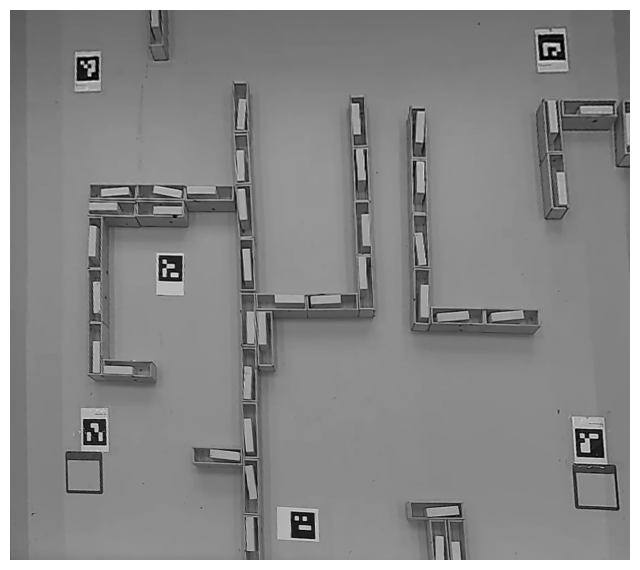

In [30]:
# Load image
img = cv2.imread('C:/Users/Armin/maze_topdown.png')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8,8))
plt.imshow(gray, cmap='gray')
plt.axis('off') 
plt.show()

Start location (pixel): (366, 599)
Goal location (pixel): (368, 602)


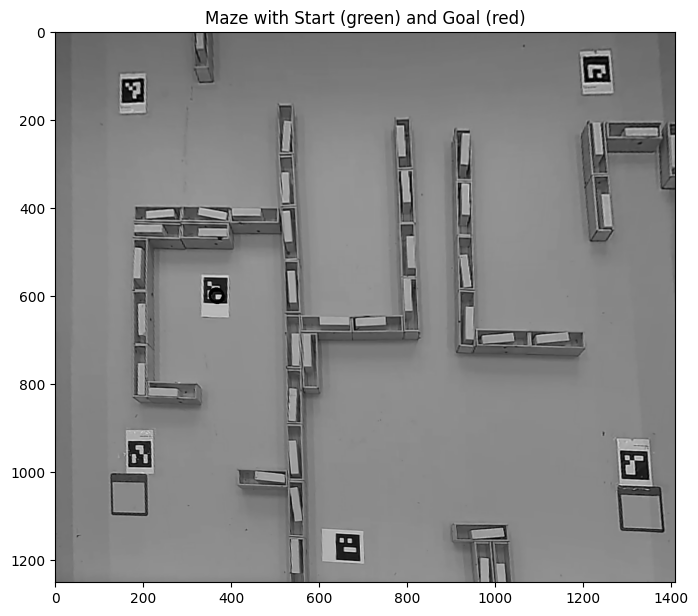

In [31]:
import cv2

# Load your provided template images (must be grayscale)
start_template = cv2.imread('C:\\Users\\Armin\\starttrain.png', 0)
goal_template = cv2.imread('C:\\Users\\Armin\\goaltrain.png', 0)

# 1. Match the start template
result_start = cv2.matchTemplate(gray, start_template, cv2.TM_CCOEFF_NORMED)
min_val1, max_val1, min_loc1, max_loc_start = cv2.minMaxLoc(result_start)
th, tw = start_template.shape
start_center = (max_loc_start[0] + tw // 2, max_loc_start[1] + th // 2)

# 2. Match the goal template
result_goal = cv2.matchTemplate(gray, goal_template, cv2.TM_CCOEFF_NORMED)
min_val2, max_val2, min_loc2, max_loc_goal = cv2.minMaxLoc(result_goal)
th, tw = goal_template.shape
goal_center = (max_loc_goal[0] + tw // 2, max_loc_goal[1] + th // 2)

print("Start location (pixel):", start_center)
print("Goal location (pixel):", goal_center)

# Continue from previous drawing
vis_img = gray.copy()
cv2.circle(vis_img, start_center, 15, (0,255,0), 3)   # Green for start
cv2.circle(vis_img, goal_center, 15, (0,0,255), 3)    # Red for goal

# Display with matplotlib (plt)
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))  # Convert color for plt
plt.title("Maze with Start (green) and Goal (red)")
plt.show()

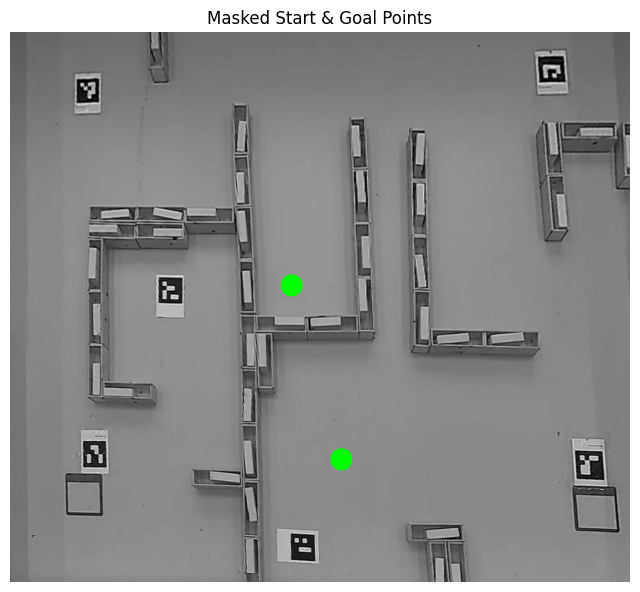

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read grayscale image (maze)
gray = cv2.imread('C:/Users/Armin/maze_topdown.png', 0)

# Define detected ceters (example values)
start_center = (640,577 )
goal_center = (753, 972)

# Create an empty mask (same size as image)
mask = np.zeros_like(gray, dtype=np.uint8)

# Draw filled circles (white = mask area)
cv2.circle(mask, start_center, 25, 255, -1)  # start point mask
cv2.circle(mask, goal_center, 25, 255, -1)   # goal point mask

# Apply mask to original image for visualization
colored = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
colored[mask > 0] = [0, 255, 0]  # highlight masked areas in green

# Visualize
plt.figure(figsize=(8, 8))
plt.imshow(colored)
plt.title("Masked Start & Goal Points")
plt.axis('off')
plt.show()



Detected 6 ArUco markers: [ 1 41  2 20  3  0]


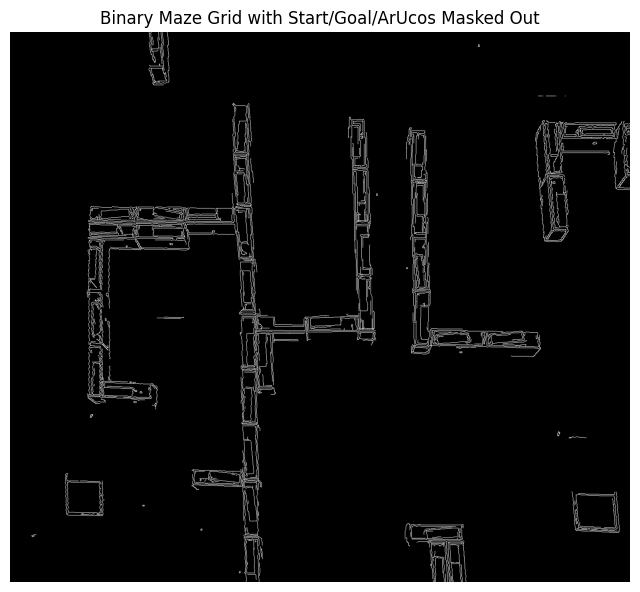

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

warped = cv2.imread('C:/Users/Armin/maze_topdown.png')  # your warped maze
if warped is not None:

    def apply_mask(mask, center, template):
        th, tw = template.shape[:2]
        padding = 0
        topleftx = max(int(center[0] - tw // 2 - padding), 0)
        toplefty = max(int(center[1] - th // 2 - padding), 0)
        bottomrightx = min(int(center[0] + tw // 2 + padding), mask.shape[1])
        bottomrighty = min(int(center[1] + th // 2 + padding), mask.shape[0])
        cv2.rectangle(mask, (topleftx, toplefty), (bottomrightx, bottomrighty), 0, -1)

    def apply_mask_center(mask, center, size=70):
        """Mask out a region given just a center point and size"""
        padding = 0
        topleftx = max(int(center[0] - size // 2 - padding), 0)
        toplefty = max(int(center[1] - size // 2 - padding), 0)
        bottomrightx = min(int(center[0] + size // 2 + padding), mask.shape[1])
        bottomrighty = min(int(center[1] + size // 2 + padding), mask.shape[0])
        cv2.rectangle(mask, (topleftx, toplefty), (bottomrightx, bottomrighty), 0, -1)

    # Convert to grayscale first
    gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    
    # Detect ArUco markers
    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    parameters = cv2.aruco.DetectorParameters()
    
    if hasattr(cv2.aruco, 'ArucoDetector'):
        detector = cv2.aruco.ArucoDetector(aruco_dict, parameters)
        corners, ids, _ = detector.detectMarkers(gray)
    else:
        corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=parameters)
    
    # Create the mask
    mazeheight, mazewidth = warped.shape[:2]
    mask = np.ones((mazeheight, mazewidth), dtype=np.uint8) * 255

    # Mask ArUcos using detected corners
    if ids is not None and len(ids) > 0:
        print(f"Detected {len(ids)} ArUco markers: {ids.flatten()}")
        
        for corner in corners:
            # Get center of each ArUco
            center = corner[0].mean(axis=0).astype(int)
            # Use apply_mask_center to mask it out
            apply_mask_center(mask, center, size=120)  # Adjust size based on your ArUco size
    else:
        print("No ArUcos detected")

    # Example start and goal (replace with your detected ones)
    start_center = (45, 70)
    goal_center = (238, 234)

    start_template = np.zeros((50, 50), dtype=np.uint8)
    goal_template = np.zeros((50, 50), dtype=np.uint8)

    # Mask start and goal
    apply_mask(mask, start_center, start_template)
    apply_mask(mask, goal_center, goal_template)

    # Apply Canny edge detection
    edges = cv2.Canny(gray, 45, 200)
    binary = cv2.bitwise_and(edges, edges, mask=mask)
    binary = (binary > 0).astype(np.uint8)

    plt.figure(figsize=(8, 8))
    plt.imshow(binary, cmap='gray')
    plt.title("Binary Maze Grid with Start/Goal/ArUcos Masked Out")
    plt.axis('off')
    plt.show()
else:
    print("Could not load warped image.")

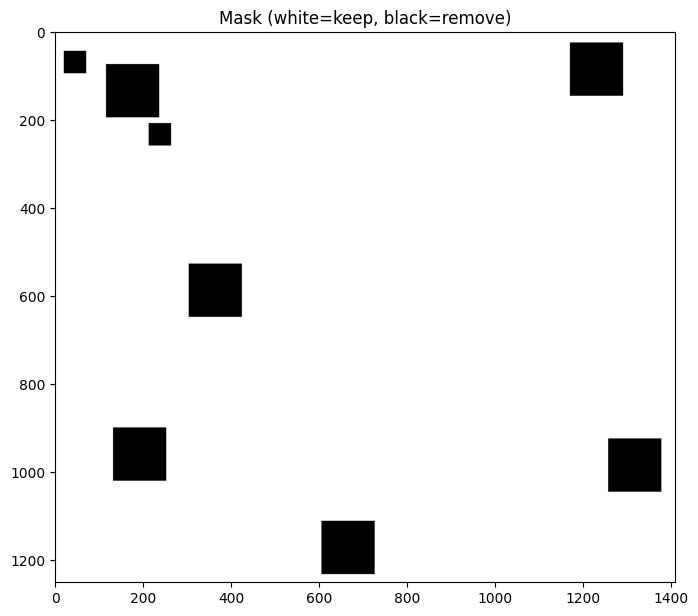

In [54]:
plt.figure(figsize=(8, 8))
plt.imshow(mask, cmap='gray')
plt.title("Mask (white=keep, black=remove)")
plt.show()

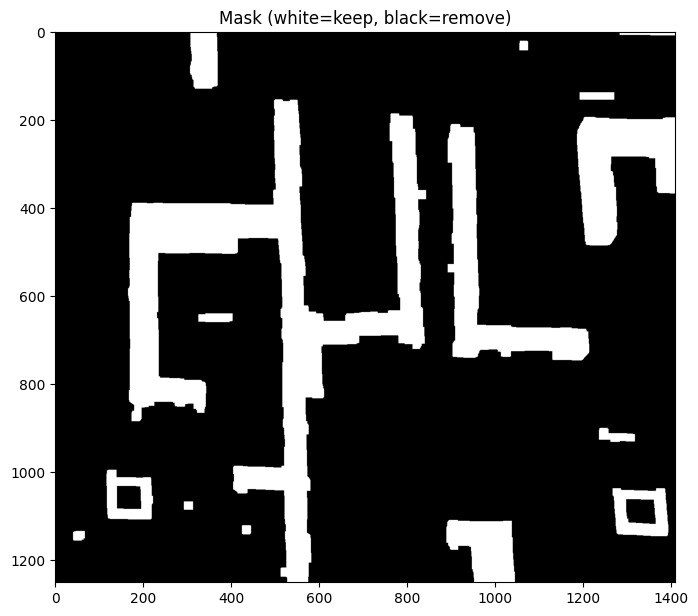

In [55]:
# Connect separated walls by expanding them
kernel = np.ones((5, 5), np.uint8)
# Apply erosion (shrinks white areas)
#eroded = cv2.erode(binary, kernel, iterations=1)
binary = cv2.dilate(binary, kernel, iterations=4)

kernel = np.ones((7, 7), np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)


plt.figure(figsize=(8, 8))
plt.imshow(binary, cmap='gray')
plt.title("Mask (white=keep, black=remove)")
plt.show()

🧮 Creating distance map...
📍 Start clearance: 37.0px (12.3cm)
🎯 Goal clearance: 42.0px (14.0cm)
⚠️  WARNING: Start position too close to wall!
⚠️  WARNING: Goal position too close to wall!

🔍 Running A* Safe Path (8-directional, 129px clearance)
   Robot radius: 99px (33cm)
   Safety margin: 30px (10cm)
✅ Found safe path (3554 waypoints)
💾 Saved: astar_path_safe_no_diag_pixels.npy (3554 waypoints)


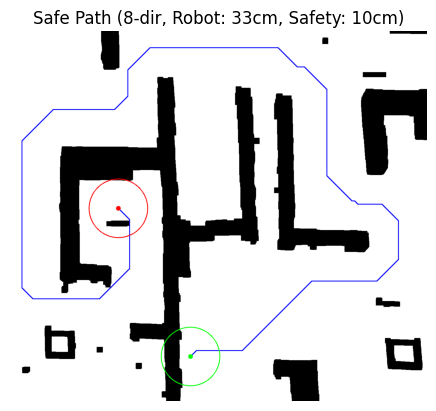

In [56]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from heapq import heappush, heappop
from scipy.ndimage import distance_transform_edt

# ================================================================
# BASIC SETTINGS
# ================================================================
ROBOT_RADIUS_CM = 33  # Robot radius in cm
PIXELS_PER_CM = 3.0
SAFETY_MARGIN_CM = 10 # Extra safety buffer

ROBOT_RADIUS_PX = int(ROBOT_RADIUS_CM * PIXELS_PER_CM)  # 99 pixels
SAFETY_MARGIN_PX = int(SAFETY_MARGIN_CM * PIXELS_PER_CM)  # 15 pixels
PREFERRED_CLEARANCE_PX = ROBOT_RADIUS_PX + SAFETY_MARGIN_PX  # 114 pixels

TURN_PENALTY_45 = 10.0
TURN_PENALTY_90 = 20.0
STRAIGHT_BONUS = 2.0  # Reward for going straight

# ================================================================
# HELPER FUNCTIONS
# ================================================================
def heuristic(a, b):
    """Octile distance for 8-directional movement."""
    dx = abs(a[0] - b[0])
    dy = abs(a[1] - b[1])
    # Octile distance: straight + diagonal
    return (dx + dy) + (1.414 - 2) * min(dx, dy)


def calculate_turn_angle(prev_dir, cur_dir):
    """Calculate the angle between two directions."""
    directions = {
        'N': 0, 'NE': 45, 'E': 90, 'SE': 135,
        'S': 180, 'SW': 225, 'W': 270, 'NW': 315
    }
    
    angle1 = directions[prev_dir]
    angle2 = directions[cur_dir]
    
    diff = abs(angle2 - angle1)
    if diff > 180:
        diff = 360 - diff
    
    return diff


def astar(maze, start, goal, distance_map):
    """
    A* pathfinding with strong preference for straight paths.
    """
    print(f"\n🔍 Running A* Safe Path (8-directional, {PREFERRED_CLEARANCE_PX}px clearance)")
    print(f"   Robot radius: {ROBOT_RADIUS_PX}px ({ROBOT_RADIUS_CM}cm)")
    print(f"   Safety margin: {SAFETY_MARGIN_PX}px ({SAFETY_MARGIN_CM}cm)")

    h, w = maze.shape
    open_set = []
    heappush(open_set, (heuristic(start, goal), 0, start, None))

    came_from = {}
    g_score = {start: 0}
    closed_set = set()

    moves = [
        (-1, 0, 1.0, 'N'),      # up
        (1, 0, 1.0, 'S'),       # down
        (0, -1, 1.0, 'W'),      # left
        (0, 1, 1.0, 'E'),       # right
        (-1, -1, 1.414, 'NW'),  # up-left (45°)
        (-1, 1, 1.414, 'NE'),   # up-right (45°)
        (1, -1, 1.414, 'SW'),   # down-left (45°)
        (1, 1, 1.414, 'SE')     # down-right (45°)
    ]

    while open_set:
        _, current_cost, current, prev_dir = heappop(open_set)
        if current in closed_set:
            continue
        closed_set.add(current)

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            path.reverse()
            print(f"✅ Found safe path ({len(path)} waypoints)")
            return np.array(path)

        y, x = current
        for dy, dx, base_cost, direction in moves:
            ny, nx = y + dy, x + dx
            neighbor = (ny, nx)

            if not (0 <= ny < h and 0 <= nx < w):
                continue
            
            if maze[ny, nx] != 0:
                continue
            
            # For diagonal moves, check corners
            if abs(dy) == 1 and abs(dx) == 1:
                if maze[y + dy, x] != 0 or maze[y, x + dx] != 0:
                    continue
            
            if neighbor in closed_set:
                continue

            move_cost = base_cost

            # STRONG turn penalty to prefer straight paths
            if prev_dir:
                angle = calculate_turn_angle(prev_dir, direction)
                if angle == 0:
                    # Continuing straight - REWARD this!
                    move_cost += STRAIGHT_BONUS
                elif angle == 45:
                    move_cost += TURN_PENALTY_45
                elif angle == 90:
                    move_cost += TURN_PENALTY_90
                elif angle == 135:
                    move_cost += TURN_PENALTY_90 * 1.8
                elif angle == 180:
                    move_cost += TURN_PENALTY_90 * 3.0  # U-turn is worst

            # Wall clearance penalty
            clearance = distance_map[ny, nx]
            if clearance < PREFERRED_CLEARANCE_PX:
                penalty_factor = ((PREFERRED_CLEARANCE_PX - clearance) / PREFERRED_CLEARANCE_PX)
                move_cost += penalty_factor * 5.0
            
            # Danger zone
            if clearance < ROBOT_RADIUS_PX:
                move_cost += 100.0

            tentative_g = g_score[current] + move_cost
            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f_score = tentative_g + heuristic(neighbor, goal)
                heappush(open_set, (f_score, tentative_g, neighbor, direction))

    print("❌ No path found.")
    return None

# ================================================================
# MAIN EXECUTION
# ================================================================
grid = binary.copy()

start = (1100,610)
goal = (599, 366)

print("🧮 Creating distance map...")
free_space = (grid == 0).astype(np.uint8)
distance_map = distance_transform_edt(free_space)

# Check if start and goal have enough clearance
start_clearance = distance_map[start]
goal_clearance = distance_map[goal]
print(f"📍 Start clearance: {start_clearance:.1f}px ({start_clearance/PIXELS_PER_CM:.1f}cm)")
print(f"🎯 Goal clearance: {goal_clearance:.1f}px ({goal_clearance/PIXELS_PER_CM:.1f}cm)")

if start_clearance < ROBOT_RADIUS_PX:
    print(f"⚠️  WARNING: Start position too close to wall!")
if goal_clearance < ROBOT_RADIUS_PX:
    print(f"⚠️  WARNING: Goal position too close to wall!")

path = astar(grid, start, goal, distance_map)

if path is not None:
    np.save("C:/Users/Armin/astar_path_safe_no_diag_pixels.npy", path)
    print(f"💾 Saved: astar_path_safe_no_diag_pixels.npy ({len(path)} waypoints)")

    vis = np.ones_like(grid) * 255
    vis[grid == 1] = 0
    vis = cv2.cvtColor(vis.astype(np.uint8), cv2.COLOR_GRAY2BGR)

    for i in range(len(path) - 1):
        p1 = (path[i][1], path[i][0])
        p2 = (path[i+1][1], path[i+1][0])
        cv2.line(vis, p1, p2, (255, 0, 0), 2)

    cv2.circle(vis, (start[1], start[0]), 8, (0, 255, 0), -1)
    cv2.circle(vis, (goal[1], goal[0]), 8, (0, 0, 255), -1)
    
    # Draw safety zone
    cv2.circle(vis, (start[1], start[0]), ROBOT_RADIUS_PX, (0, 255, 0), 2)
    cv2.circle(vis, (goal[1], goal[0]), ROBOT_RADIUS_PX, (0, 0, 255), 2)

    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Safe Path (8-dir, Robot: {ROBOT_RADIUS_CM}cm, Safety: {SAFETY_MARGIN_CM}cm)")
    plt.axis("off")
    plt.show()

In [58]:
import numpy as np

# ================================================================
# SETTINGS
# ================================================================
PIXELS_PER_CM = 3.0
IMAGE_HEIGHT = 1251 # Your image height in pixels

# Maze origin in real-world coordinates (bottom-left corner in cm)
MAZE_ORIGIN_X = 0.0  # Adjust if your maze doesn't start at (0,0)
MAZE_ORIGIN_Y = 0.0

# ================================================================
# CONVERSION
# ================================================================
# Load path in pixels (row, col)
path_pixels = np.load("astar_path_safe_no_diag_pixels.npy")

print(f"📍 Converting {len(path_pixels)} waypoints to cartesian coordinates...")

# Convert to cartesian (x, y) in cm
# Image coordinates: (0,0) is top-left, row increases downward
# Cartesian coordinates: (0,0) is bottom-left, y increases upward
path_cartesian = np.zeros_like(path_pixels, dtype=np.float64)

for i, (row, col) in enumerate(path_pixels):
    # Convert pixel to cm
    x_cm = col / PIXELS_PER_CM
    y_cm = (IMAGE_HEIGHT - row) / PIXELS_PER_CM  # Flip Y-axis
    
    # Add origin offset if needed
    path_cartesian[i] = [x_cm + MAZE_ORIGIN_X, y_cm + MAZE_ORIGIN_Y]

# Save cartesian path
np.save("astar_path_cartesian.npy", path_cartesian)
print(f"✅ Saved: astar_path_cartesian.npy")
print(f"   Start: ({path_cartesian[0][0]:.2f}, {path_cartesian[0][1]:.2f}) cm")
print(f"   Goal:  ({path_cartesian[-1][0]:.2f}, {path_cartesian[-1][1]:.2f}) cm")
print(f"   Total waypoints: {len(path_cartesian)}")

📍 Converting 3554 waypoints to cartesian coordinates...
✅ Saved: astar_path_cartesian.npy
   Start: (203.33, 50.33) cm
   Goal:  (122.00, 217.33) cm
   Total waypoints: 3554


📍 Original path: 3554 waypoints
✅ Simplified path: 28 waypoints
   Reduced by 99.2%
   Start: (203.33, 50.33) cm
   Goal:  (122.00, 217.33) cm
💾 Saved: astar_path_simplified.npy


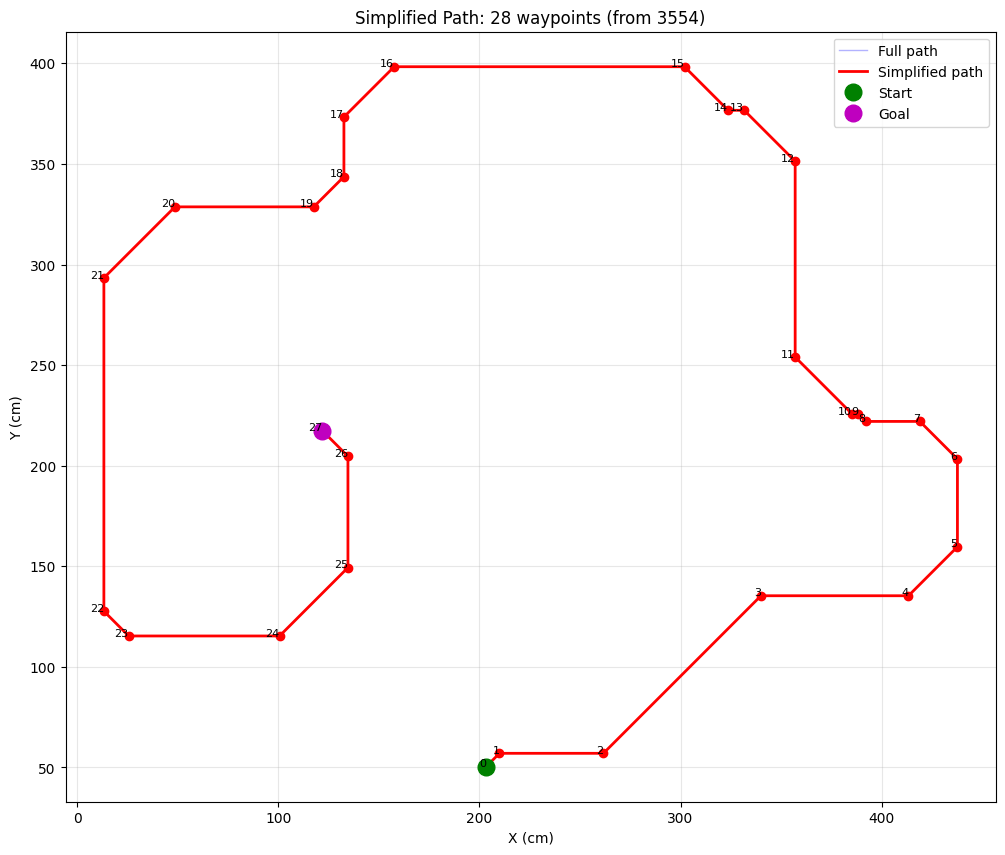


📋 Waypoints (first 10):
   [0] (203.33, 50.33)
   [1] (210.00, 57.00)
   [2] (261.67, 57.00)
   [3] (340.00, 135.33)
   [4] (413.33, 135.33)
   [5] (437.67, 159.67)
   [6] (437.67, 203.33)
   [7] (419.00, 222.00)
   [8] (392.00, 222.00)
   [9] (388.33, 225.67)


In [59]:
import numpy as np
import matplotlib.pyplot as plt

# ================================================================
# SIMPLIFICATION
# ================================================================
def simplify_path(path, angle_threshold=5.0):
    """
    Keep only waypoints where direction changes significantly.
    
    Args:
        path: Array of (x, y) coordinates
        angle_threshold: Minimum angle change in degrees to keep a point
    
    Returns:
        Simplified path with only turning points
    """
    if len(path) <= 2:
        return path
    
    simplified = [path[0]]  # Always keep start
    
    for i in range(1, len(path) - 1):
        prev = simplified[-1]  # Last kept point
        curr = path[i]
        next_pt = path[i + 1]
        
        # Direction vectors
        v1 = curr - prev
        v2 = next_pt - curr
        
        # Skip if either vector is too short (consecutive points)
        if np.linalg.norm(v1) < 1e-6 or np.linalg.norm(v2) < 1e-6:
            continue
        
        # Calculate angle between vectors
        cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        cos_angle = np.clip(cos_angle, -1.0, 1.0)  # Handle numerical errors
        angle = np.degrees(np.arccos(cos_angle))
        
        # Keep point if direction changes significantly
        if angle > angle_threshold:
            simplified.append(curr)
    
    simplified.append(path[-1])  # Always keep goal
    
    return np.array(simplified)

# ================================================================
# LOAD AND SIMPLIFY
# ================================================================
path_full = np.load("astar_path_cartesian.npy")
print(f"📍 Original path: {len(path_full)} waypoints")

# Simplify with 5-degree threshold (adjust as needed)
path_simplified = simplify_path(path_full, angle_threshold=5.0)

print(f"✅ Simplified path: {len(path_simplified)} waypoints")
print(f"   Reduced by {100 * (1 - len(path_simplified)/len(path_full)):.1f}%")
print(f"   Start: ({path_simplified[0][0]:.2f}, {path_simplified[0][1]:.2f}) cm")
print(f"   Goal:  ({path_simplified[-1][0]:.2f}, {path_simplified[-1][1]:.2f}) cm")

# Save simplified path
np.save("astar_path_simplified.npy", path_simplified)
print(f"💾 Saved: astar_path_simplified.npy")

# ================================================================
# VISUALIZATION
# ================================================================
plt.figure(figsize=(12, 10))

# Plot full path (light)
plt.plot(path_full[:, 0], path_full[:, 1], 'b-', alpha=0.3, linewidth=1, label='Full path')

# Plot simplified path (bold)
plt.plot(path_simplified[:, 0], path_simplified[:, 1], 'r-', linewidth=2, label='Simplified path')
plt.plot(path_simplified[:, 0], path_simplified[:, 1], 'ro', markersize=6)

# Mark start and goal
plt.plot(path_simplified[0][0], path_simplified[0][1], 'go', markersize=12, label='Start')
plt.plot(path_simplified[-1][0], path_simplified[-1][1], 'mo', markersize=12, label='Goal')

# Add waypoint numbers
for i, point in enumerate(path_simplified):
    plt.text(point[0], point[1], str(i), fontsize=8, ha='right')

plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title(f'Simplified Path: {len(path_simplified)} waypoints (from {len(path_full)})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

# Print waypoints for debugging
print(f"\n📋 Waypoints (first 10):")
for i in range(min(10, len(path_simplified))):
    print(f"   [{i}] ({path_simplified[i][0]:.2f}, {path_simplified[i][1]:.2f})")

In [ ]:
from irobot_edu_sdk.backend.bluetooth import Bluetooth
from irobot_edu_sdk.robots import event, hand_over, Color, Robot, Root, Create3
from irobot_edu_sdk.music import Note

# Connect to your robot
robot = Create3(Bluetooth("Robot 3"))  # Use Create3, not Root!

# Test 1: Simple movement
@event(robot.when_play)
async def play(robot):
    print("🤖 Starting test sequence...")
    
    # Move forward 20cm
    print("⬆️ Moving forward 20cm...")
    await robot.move(20)
    
    # Turn right 90 degrees
    print("➡️ Turning right 90°...")
    await robot.turn_right(90)
    
    # Move forward 20cm
    print("⬆️ Moving forward 20cm...")
    await robot.move(20)
    
    # Play success sound
    await robot.play_note(Note.A5, 0.5)
    
    print("✅ Test complete!")

# Start the program
robot.play()